In [ ]:
import polars as pl
import json
import matplotlib.pyplot as plt

In [93]:
with open('resultados_simulacion_optimizada_10_seeds.json', 'r') as f:
    resultados = json.load(f)

In [94]:
data = pl.DataFrame(resultados)

In [106]:
data.with_columns(
    pl.col('donaciones_delta').list.std().alias('donaciones_std'),
).sort('donaciones_std')

W_NOR_POS,W_NOR_NEG,W_EMP_POS,W_EMP_NEG,susceptibilidaes,donaciones_delta,donaciones_std,suscept_std
f64,f64,f64,f64,list[f64],list[f64],f64,f64
0.0,0.0,0.0,0.0,"[0.000525, 0.000852, … 0.499236]","[0.081662, 0.137857, … 0.657869]",0.06081,0.001988
0.0,0.0,0.333333,0.0,"[0.00053, 0.00086, … 0.5]","[0.08167, 0.137872, … 0.65793]",0.060955,0.002221
0.333333,0.0,0.0,0.0,"[0.000561, 0.0009, … 0.5]","[0.08169, 0.137997, … 0.657863]",0.06099,0.002909
0.0,0.0,0.666667,0.0,"[0.000535, 0.000867, … 0.5]","[0.081677, 0.137889, … 0.658144]",0.061075,0.002734
0.666667,0.0,0.0,0.0,"[0.00059, 0.000932, … 0.5]","[0.081704, 0.138114, … 0.658435]",0.061084,0.002658
…,…,…,…,…,…,…,…
0.666667,1.0,0.0,1.0,"[3.5594e-36, 1.1258e-35, … 0.021869]","[0.011631, 0.018131, … 0.625775]",0.13353,0.000042
1.0,1.0,1.0,1.0,"[3.8084e-36, 1.2553e-35, … 0.101411]","[0.011631, 0.01813, … 0.62121]",0.134926,0.000237
1.0,1.0,0.666667,1.0,"[3.8130e-36, 1.2574e-35, … 0.100234]","[0.011631, 0.01813, … 0.621292]",0.134935,0.000234


In [90]:
def plot(plot_data: pl.DataFrame,variable:str,xlimits=1,ylimits=500):    
    fig, ax = plt.subplots(figsize=(10, 6), ncols=4, nrows=4)

    
    # flatten axes for easy indexing
    axes = ax.ravel()
    max_plots = axes.size

    # initialize local plot index and plot up to available subplots
    plot_idx = 0

    for row in plot_data.iter_rows(named=True):
        if plot_idx >= max_plots:
            break

        W_NOR_POS = float(row['W_NOR_POS'])
        W_NOR_NEG = float(row['W_NOR_NEG'])
        variable_data = row[variable]

        axes[plot_idx].hist(variable_data, bins=10)
        # plot a vertical line at average donation delta
        avg_donacion = sum(variable_data) / len(variable_data)
        axes[plot_idx].axvline(avg_donacion, color='red', linestyle='dashed', linewidth=1)
        axes[plot_idx].set_title(f"W_NOR_POS={round(W_NOR_POS,2)}\nW_NOR_NEG={round(W_NOR_NEG,2)}", fontsize=8)
        axes[plot_idx].set_xlim(0,xlimits)
        axes[plot_idx].set_ylim(0,ylimits)

        plot_idx += 1

    # turn off any unused subplots
    for i in range(plot_idx, max_plots):
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()


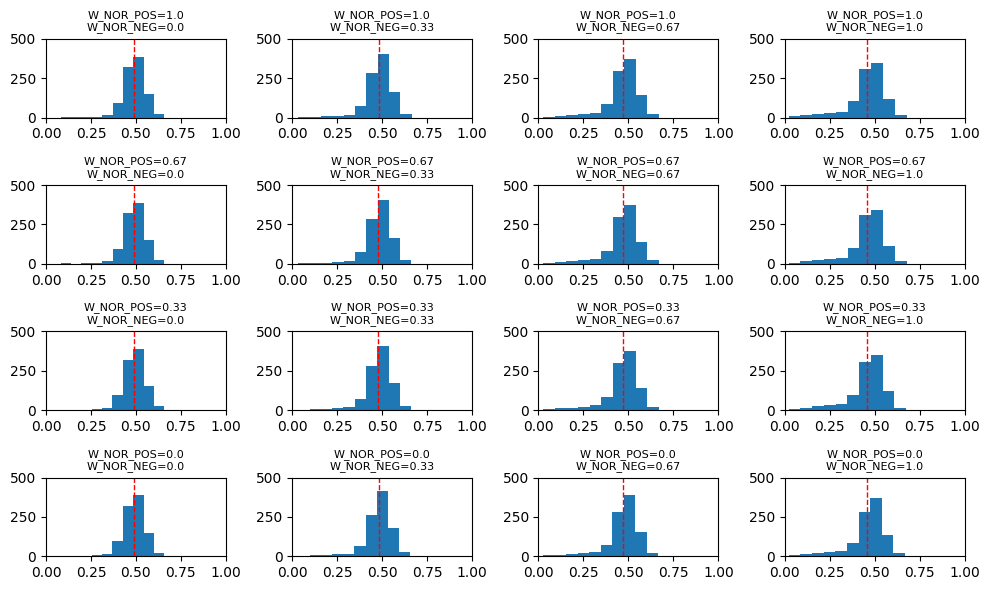

In [91]:
# select subset
plot_data = data.filter(pl.col('W_EMP_POS').eq(0) & pl.col('W_EMP_NEG').eq(0)).sort('W_NOR_POS', descending=True)
plot(plot_data, 'donaciones_delta',xlimits=1,ylimits=500)

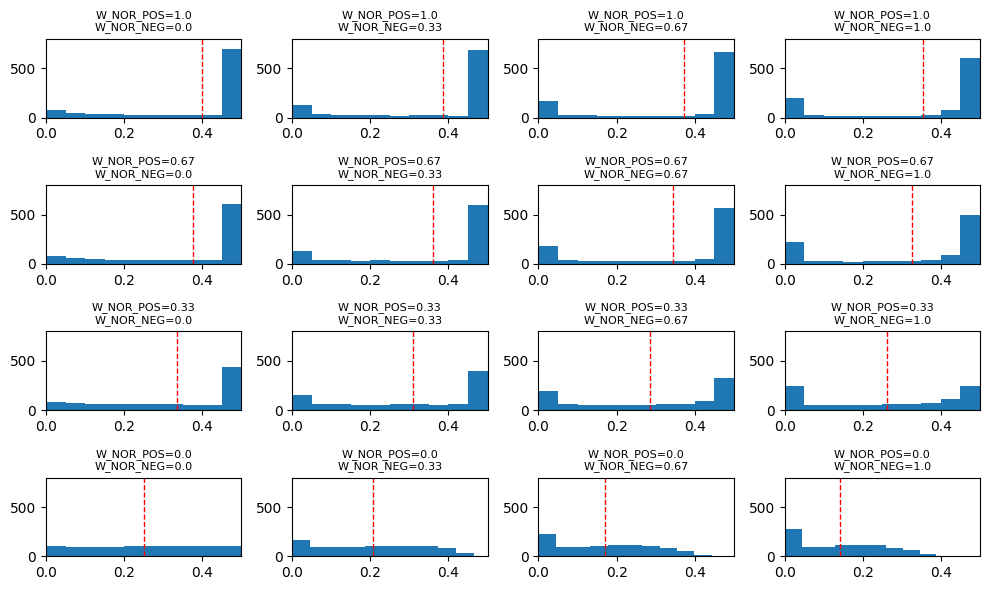

In [92]:
plot(plot_data, 'susceptibilidaes',xlimits=.5,ylimits=800)